In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Loading Dataset using Pandas

In [2]:
df = pd.read_csv('Temperature.csv')
df.shape

(96453, 6)

In [3]:
df.head()

,Humi,WindSp,WindBe,Visi,Pres,Temp
0,0.89,14.1197,251,15.8263,1015.13,9.472222
1,0.86,14.2646,259,15.8263,1015.63,9.355556
2,0.89,3.9284,204,14.9569,1015.94,9.377778
3,0.83,14.1036,269,15.8263,1016.41,8.288889
4,0.83,11.0446,259,15.8263,1016.51,8.755556


## Summary Statistics and Null Value Detection

In [4]:
df.describe()

,Humi,WindSp,WindBe,Visi,Pres,Temp
count,96453.000000,96448.000000,96453.000000,96449.000000,96453.000000,96449.000000
mean,0.734899,10.810286,187.509232,10.347195,1003.235956,11.932146
std,0.195473,6.913508,107.383428,4.192136,116.969906,9.551380
min,0.000000,0.000000,0.000000,0.000000,0.000000,-21.822222
25%,0.600000,5.828200,116.000000,8.339800,1011.900000,4.688889
50%,0.780000,9.965900,180.000000,10.046400,1016.450000,12.000000
75%,0.890000,14.135800,290.000000,14.812000,1021.090000,18.838889
max,1.000000,63.852600,359.000000,16.100000,1046.380000,39.905556


In [5]:
df.isna().sum() # WindSp has 5 null values, Visi has 4, and Temp has 4

Humi      0
WindSp    5
WindBe    0
Visi      4
Pres      0
Temp      4
dtype: int64

In [6]:
df[df.isna().any(axis = 1)].reset_index() # Only print rows with NaN values

,index,Humi,WindSp,WindBe,Visi,Pres,Temp
0,11,0.54,NaN,316,11.4471,1017.74,17.144444
1,12,0.55,NaN,281,11.2700,1017.59,17.800000
2,13,0.51,NaN,289,11.2700,1017.48,17.333333
3,14,0.47,NaN,262,11.4471,1017.17,18.877778
4,15,0.46,NaN,288,11.2700,1016.47,18.911111
5,23714,0.90,14.4095,271,NaN,1010.80,13.711111
6,23715,0.90,3.1717,178,NaN,1010.57,13.155556
7,23716,0.93,5.7477,196,NaN,1010.63,11.800000
8,23717,0.96,3.3005,237,NaN,1010.68,12.644444
9,31259,0.67,11.2217,328,11.0768,1015.00,NaN


## Missing Value Filling

In [7]:
df.Humi.mean(), df.WindSp.mean(), df.Temp.mean()

(np.float64(0.7348989663359357),
 np.float64(10.810286140718315),
 np.float64(11.932145889430187))

In [8]:
df.Humi = df.Humi.ffill() # Forward Fill
df.WindSp = df.WindSp.bfill() # Backward Fill
df.Temp = df.Temp.ffill() # Forward Fill

In [9]:
df.Humi.info(), df.WindSp.info(), df.Temp.info()

<class 'pandas.Series'>
RangeIndex: 96453 entries, 0 to 96452
Series name: Humi
Non-Null Count  Dtype  
--------------  -----  
96453 non-null  float64
dtypes: float64(1)
memory usage: 753.7 KB
<class 'pandas.Series'>
RangeIndex: 96453 entries, 0 to 96452
Series name: WindSp
Non-Null Count  Dtype  
--------------  -----  
96453 non-null  float64
dtypes: float64(1)
memory usage: 753.7 KB
<class 'pandas.Series'>
RangeIndex: 96453 entries, 0 to 96452
Series name: Temp
Non-Null Count  Dtype  
--------------  -----  
96453 non-null  float64
dtypes: float64(1)
memory usage: 753.7 KB


(None, None, None)

## Visualization and Further Preprocessing

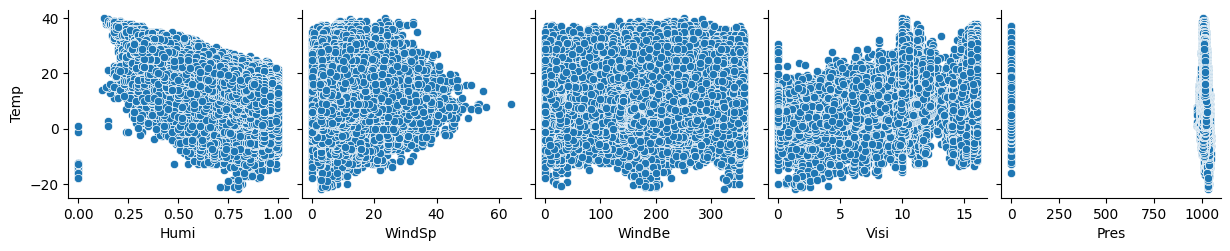

In [10]:
sns.pairplot(data = df, x_vars = ['Humi', 'WindSp', 'WindBe', 'Visi', 'Pres'], y_vars = 'Temp') # The features appear to have no colinearity with each other, only affect the dependent variable 'Temperature'
plt.show()

In [11]:
df = df[df.Pres > 0]
df.shape

(95165, 6)

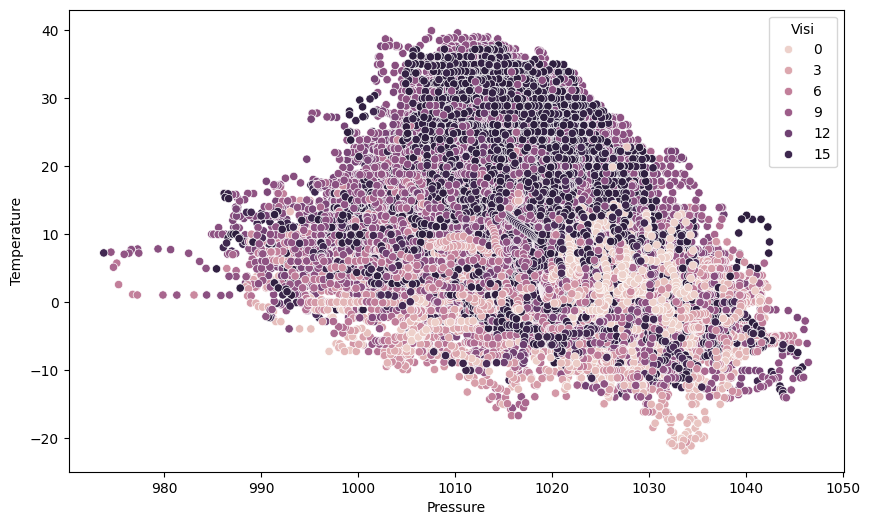

In [12]:
plt.figure(figsize = (10, 6)) 
sns.scatterplot(data = df, x = df.Pres, y = df.Temp, hue = df.Visi) # The features appear to have no colinearity with each other, only affect the dependent variable 'Temperature'
plt.xlabel('Pressure')
plt.ylabel('Temperature')
plt.show() # Holds a relationship which is much better than before. Might be a higher order polynomial

## Scaling the Data

In [14]:
transform = StandardScaler()
X = transform.fit_transform(df[['Humi', 'WindSp', 'WindBe', 'Visi', 'Pres']])
Y = df.Temp.to_numpy().reshape((X.shape[0], 1))

In [15]:
X, Y

(array([[ 0.79266244,  0.48398504,  0.59188853,  1.30054433, -0.21651736],
        [ 0.639279  ,  0.5050098 ,  0.66637273,  1.30054433, -0.15223608],
        [ 0.79266244, -0.9947569 ,  0.15429388,  1.09286968, -0.11238169],
        ...,
        [-0.89455542, -0.26122615, -1.46573739,  1.36592339, -0.14837921],
        [-0.69004417, -0.03696197, -1.55884264,  1.36592339, -0.11109607],
        [-0.63891635, -0.71209059, -1.38194267,  1.22747362, -0.08409793]],
       shape=(95165, 5)),
 array([[ 9.47222222],
        [ 9.35555556],
        [ 9.37777778],
        ...,
        [22.03888889],
        [21.52222222],
        [20.43888889]], shape=(95165, 1)))

## Preparing the Dataset for Direct Training

In [16]:
np.save('X.npy', X)
np.save('Y.npy', Y)

In [ ]:
# Directly load the numpy arrays into X and Y for training purposes

## Key EDA Insights

In [17]:
for column in df.columns:
    print(df[column].corr(df.Temp))

-0.6327771308907992
0.010177877862271418
0.03077887686536556
0.39242159039118024
-0.3104566941275026
1.0


In [ ]:
# Sometimes even 0 correlation features are important. They can be dropped depending on the model being used. Try running your model on the 
# complete dataset and see the accuracy. Afterwards, run this cell to drop the columns with no correlation with the target and
# save it again to check the difference

df.drop(columns = ['WindSp', 'WindBe'], inplace = True)
transform = StandardScaler()
X = transform.fit_transform(df[['Humi', 'WindSp', 'WindBe', 'Visi', 'Pres']])
Y = df.Temp.to_numpy().reshape((Y.shape[0], 1))
np.save('X.npy', X)
np.save('Y.npy', Y)

In [18]:
grouped_df = df.groupby('Temp')
idx = 0
for group, dfx in grouped_df:
    print(group)
    print(dfx)
    if idx == 500:
        break
    idx += 1

# A combination of features expect the target indicating that despite less correlation, all of the features are necessary

-21.82222222
       Humi  WindSp  WindBe    Visi     Pres       Temp
54847   0.8  3.0751     323  1.3685  1033.66 -21.822222
-21.11111111
       Humi  WindSp  WindBe   Visi    Pres       Temp
55490  0.74    3.22     200  1.932  1034.3 -21.111111
55493  0.78    4.83     180  2.576  1033.3 -21.111111
55494  0.71    3.22     190  1.932  1032.6 -21.111111
-20.78333333
       Humi  WindSp  WindBe    Visi     Pres       Temp
55495   0.8  4.4275     181  1.7871  1032.33 -20.783333
-20.55555556
       Humi  WindSp  WindBe   Visi    Pres       Temp
54866  0.78    6.44      30  1.449  1032.1 -20.555556
55491  0.78    3.22     200  4.025  1033.8 -20.555556
-20.27777778
       Humi  WindSp  WindBe    Visi     Pres       Temp
55492  0.79  5.6672     158  1.8032  1033.53 -20.277778
-20.05
       Humi  WindSp  WindBe    Visi     Pres   Temp
55489  0.78  6.2146     170  1.7066  1034.74 -20.05
-20.0
       Humi  WindSp  WindBe   Visi    Pres  Temp
54845  0.82    8.05     340  1.449  1032.6 -20.0
54846 

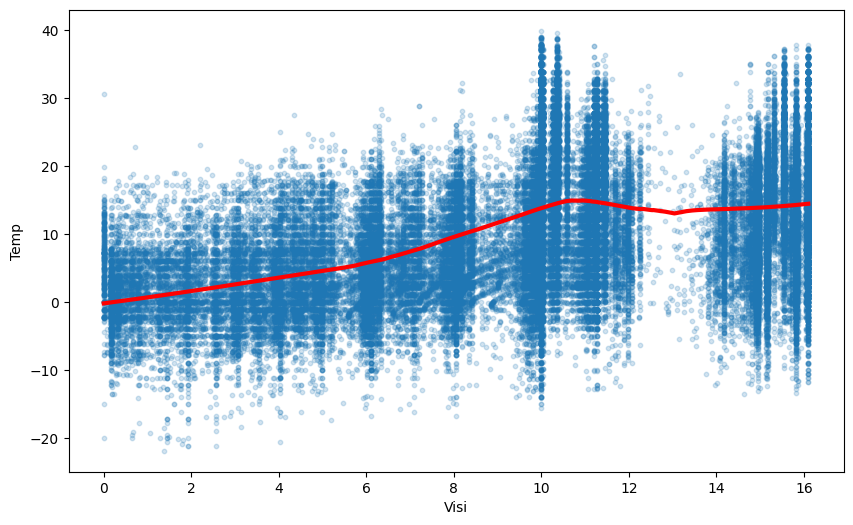

In [19]:
plt.figure(figsize = (10,6))
sns.regplot(data = df, x = "Visi", y = "Temp", lowess = True, scatter_kws = {"alpha" : 0.2, "s" : 10}, line_kws = {"color" : "red", "linewidth" : 3})

plt.show()

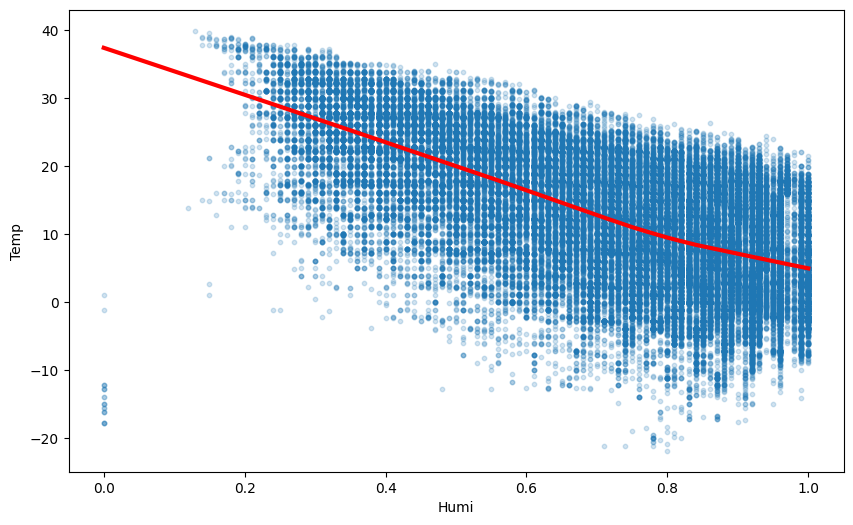

In [20]:
plt.figure(figsize = (10,6))
sns.regplot(data = df, x = "Humi", y = "Temp", lowess = True, scatter_kws = {"alpha" : 0.2, "s" : 10}, line_kws = {"color" : "red", "linewidth" : 3})

plt.show()

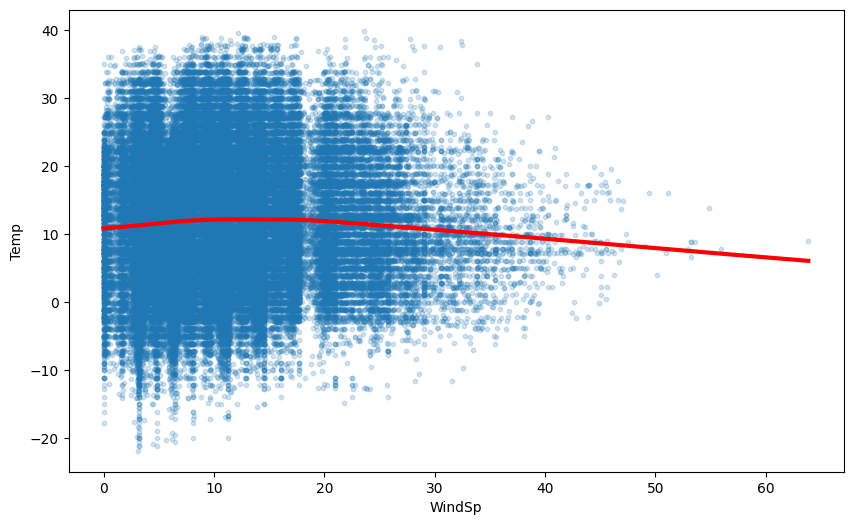

In [21]:
plt.figure(figsize = (10,6))
sns.regplot(data = df, x = "WindSp", y = "Temp", lowess = True, scatter_kws = {"alpha" : 0.2, "s" : 10}, line_kws = {"color" : "red", "linewidth" : 3})

plt.show()

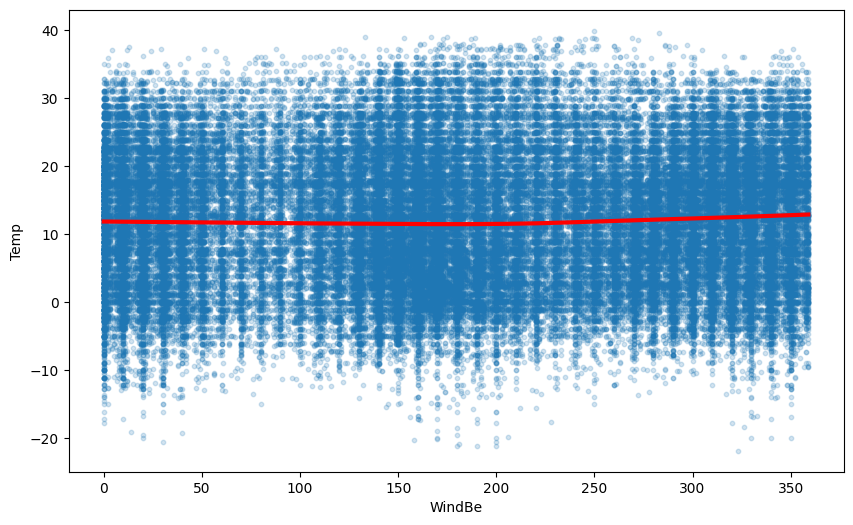

In [22]:
plt.figure(figsize = (10,6))
sns.regplot(data = df, x = "WindBe", y = "Temp", lowess = True, scatter_kws = {"alpha" : 0.2, "s" : 10}, line_kws = {"color" : "red", "linewidth" : 3})

plt.show()

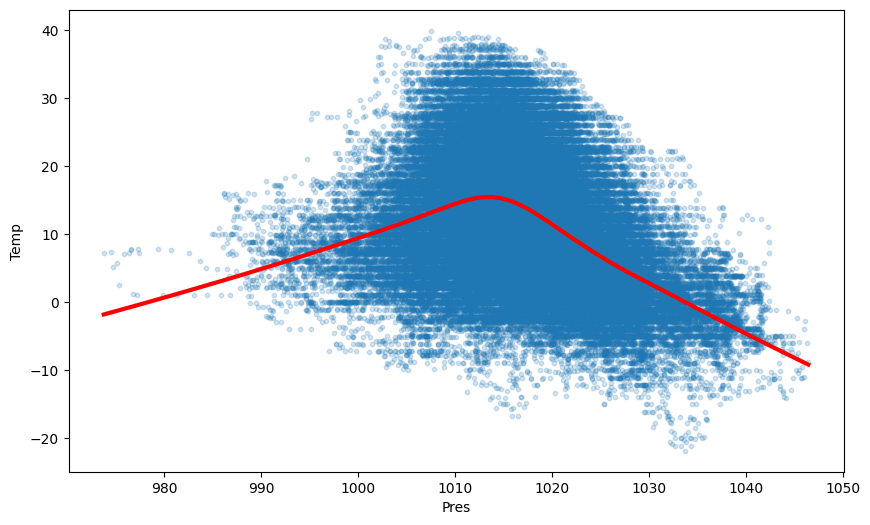

In [23]:
plt.figure(figsize = (10,6))
sns.regplot(data = df, x = "Pres", y = "Temp", lowess = True, scatter_kws = {"alpha" : 0.2, "s" : 10}, line_kws = {"color" : "red", "linewidth" : 3})

plt.show()

In [24]:
# A quadratic relationship will suit Pressure better

In [25]:
# All of the relationships with the target are nearly linear. When the features will be combined, it'll become a smooth curve for the target prediction
# In case the MSE is too high, we can fit neural network models to get different functions which will better suit the data